In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os

In [2]:
# merge all csv files in a folder into a single dataframe if they start with 'all_results_'
def merge_csv_files(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.startswith('all_results_') and f.endswith('.csv')]
    print(all_files)
    df_list = []
    for file in all_files:
        print(file)
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df_list.append(df)
    merged_df = pd.concat(df_list, ignore_index=True)
    return merged_df

data_folder = './results/'
df = merge_csv_files(data_folder)

['all_results_NCI1_20260119-151529.csv', 'all_results_ogbg-molhiv_20260126-091023.csv', 'all_results_EXPWL1_20260119-151536.csv', 'all_results_ogbg-molhiv_20260123-144804.csv', 'all_results_ogbg-molhiv_20260123-230924.csv', 'all_results_MUTAG_20260119-151524.csv']
all_results_NCI1_20260119-151529.csv
all_results_ogbg-molhiv_20260126-091023.csv
all_results_EXPWL1_20260119-151536.csv
all_results_ogbg-molhiv_20260123-144804.csv
all_results_ogbg-molhiv_20260123-230924.csv
all_results_MUTAG_20260119-151524.csv


In [11]:

curr_df = df[df['dataset'].isin(datasets)]
pooling_renaming = {
    'acc': 'ACC',
    'ccpool': 'CCPool',
    'dmon': 'DMoN',
    'hosc': 'HOSC',
    'jb': 'JBPool',
    'kmis': r'\textit{k}-MIS',
    'maxcut': 'MaxCut',
    'nopool': 'No Pooling',
}
curr_df['pooling'] = curr_df['pooling'].map(pooling_renaming)
# order the pooling methods
pooling_order = ['CCPool', 'JBPool', 'HOSC', 'DMoN', 'ACC', r'\textit{k}-MIS', 'MaxCut','No Pooling', ]
curr_df['pooling'] = pd.Categorical(curr_df['pooling'], categories=pooling_order, ordered=True)

    
# create a summary table with mean and std of best_test_acc for each pooling method and dataset
summary_table = curr_df.groupby(['dataset', 'pooling'])['best_test_acc'].agg(['mean', 'sem']).reset_index()
roc_auc = curr_df.groupby(['dataset', 'pooling'])['best_test_rocauc'].agg(['mean', 'sem']).reset_index()
roc_auc.dropna(inplace=True)
roc_auc['roc_auc'] = roc_auc.apply(lambda row: f"{row['mean']*100:.1f} ± {row['sem']*100:.1f}", axis=1)
roc_auc = roc_auc.pivot(index='pooling', columns='dataset')
roc_auc = roc_auc['roc_auc'].reset_index()
roc_auc.columns.name = None
roc_auc.set_index('pooling', inplace=True)

summary_table.dropna(inplace=True)
# the dataset should be the columns, pooling the rows, each cell with mean ± std
summary_table['acc'] = summary_table.apply(lambda row: f"{row['mean']*100:.1f} ± {row['sem']*100:.1f}", axis=1)
summary_pivot = summary_table.pivot(index='pooling', columns='dataset')
summary_final = summary_pivot['acc'].reset_index()
# remove the first column multiindex column
summary_final.columns.name = None
summary_final.set_index('pooling', inplace=True)
summary_final['ogbg-molhiv'] = roc_auc['ogbg-molhiv']
# add a column with ogbg-molhiv with the best_test_rocauc avg and sem
summary_final.to_latex('pooling_summary_table.tex')
summary_final

/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_25043/2921690732.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = curr_df.groupby(['dataset', 'pooling'])['best_test_acc'].agg(['mean', 'sem']).reset_index()
/var/folders/jn/nw79qpfd0812n0rw61rbzj0c0000gn/T/ipykernel_25043/2921690732.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roc_auc = curr_df.groupby(['dataset', 'pooling'])['best_test_rocauc'].agg(['mean', 'sem']).reset_index()


,EXPWL1,MUTAG,NCI1,ogbg-molhiv
pooling,,,,
CCPool,99.9 ± 0.0,87.9 ± 1.8,77.7 ± 0.7,79.6 ± 0.7
JBPool,98.7 ± 0.3,82.0 ± 2.3,78.9 ± 0.4,77.6 ± 0.9
HOSC,91.8 ± 0.7,85.1 ± 2.3,77.8 ± 1.0,79.0 ± 0.6
DMoN,96.3 ± 0.8,84.8 ± 1.9,77.5 ± 0.7,79.6 ± 0.8
ACC,93.3 ± 1.1,91.6 ± 1.9,78.0 ± 0.6,79.3 ± 0.8
\textit{k}-MIS,99.8 ± 0.1,81.6 ± 2.7,77.9 ± 0.8,79.5 ± 0.8
MaxCut,99.6 ± 0.2,76.1 ± 3.0,76.9 ± 0.4,78.0 ± 1.0
No Pooling,99.2 ± 0.2,87.0 ± 1.8,79.6 ± 0.7,80.9 ± 0.7


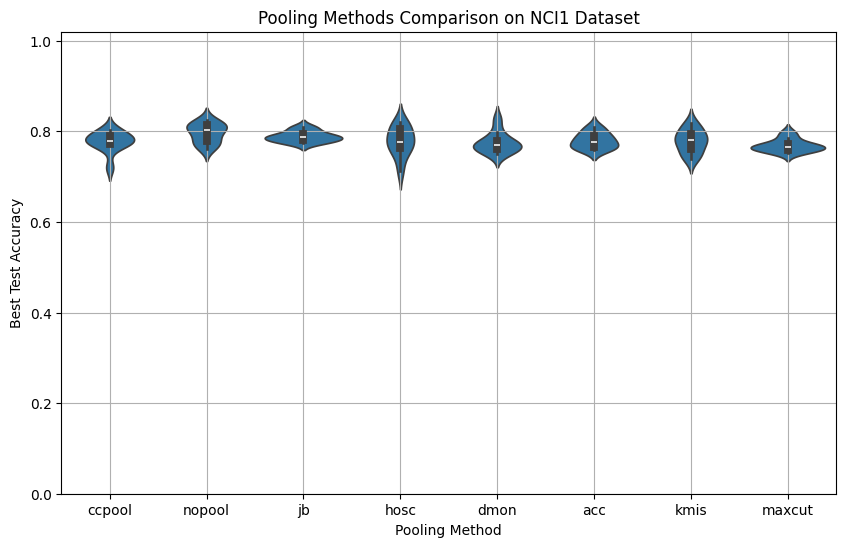

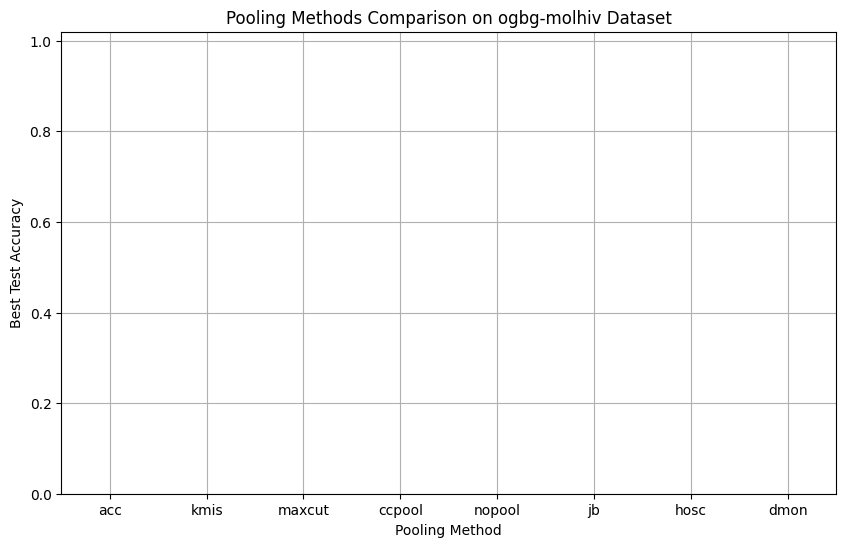

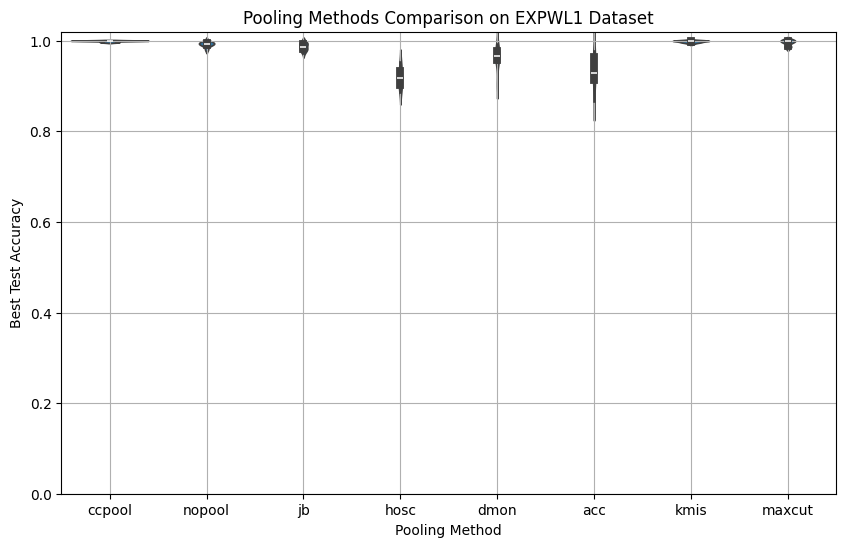

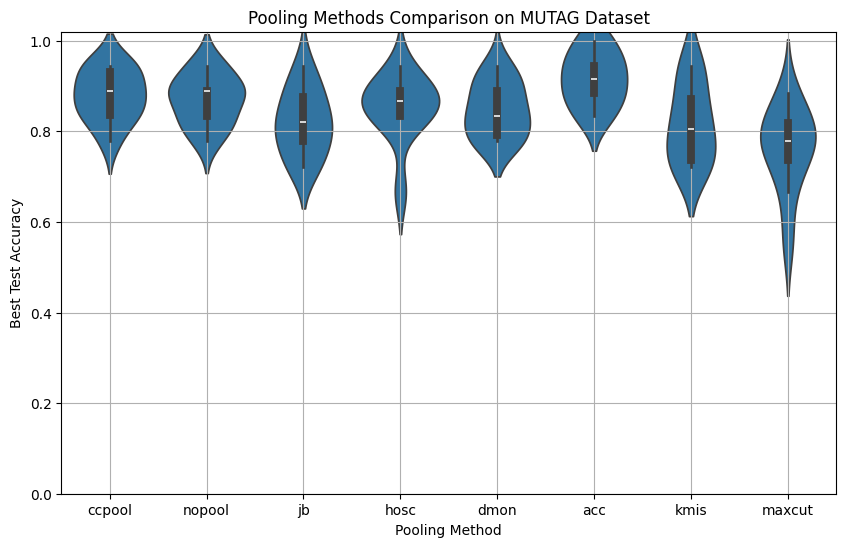

In [12]:
# plot the results for each dataset in a separate figure
datasets = df['dataset'].unique()
datasets = [dataset for dataset in datasets ]
for dataset in datasets:
    df_dataset = df[df['dataset'] == dataset]
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_dataset, x='pooling', y='best_test_acc')
    plt.title(f'Pooling Methods Comparison on {dataset} Dataset')
    plt.ylabel('Best Test Accuracy')
    plt.xlabel('Pooling Method')
    plt.ylim(0, 1.02)
    plt.grid(True)
    # plt.savefig(f'pooling_comparison_{dataset}.png')